# Predicting housing prices in Washington

#### Kyan and Rene

Where we got the data: https://github.com/viviandng/KC_House_Price/blob/master/kc_house_data.csv

This data set is a collection of prices of houses that were sold in the King County of Washington state. Each house has a rating, sold price, number of bedrooms, square footage, and other attributes. In this notebook, we will be predicting the price of houses using the factors of bedroom counts, location, etc. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.model_selection import learning_curve, GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn import tree
from IPython.display import display, HTML

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# suppress futurewarnings only
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
sns.set_theme(context='notebook', style='whitegrid')

# set default plot size
plt.rcParams['figure.figsize'] = 6,4

In [3]:
display(HTML("<style>.container { width:90% !important; }</style>"))

In [4]:
input_file = "kc_house_data.csv"
df = pd.read_csv(input_file)

## Data Preprocessing

In [5]:
df.drop(['id', 'lat','long','yr_renovated', 'view', 'waterfront', 'zipcode', 'date', 'sqft_basement'], axis=1, inplace=True)
df.dropna()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,yr_built,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,3,7,1180,1955,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,3,7,2170,1951,1690,7639
2,180000.0,2,1.00,770,10000,1.0,3,6,770,1933,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,5,7,1050,1965,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,3,8,1680,1987,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...
21592,360000.0,3,2.50,1530,1131,3.0,3,8,1530,2009,1530,1509
21593,400000.0,4,2.50,2310,5813,2.0,3,8,2310,2014,1830,7200
21594,402101.0,2,0.75,1020,1350,2.0,3,7,1020,2009,1020,2007
21595,400000.0,3,2.50,1600,2388,2.0,3,8,1600,2004,1410,1287


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21597 non-null  float64
 1   bedrooms       21597 non-null  int64  
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  int64  
 4   sqft_lot       21597 non-null  int64  
 5   floors         21597 non-null  float64
 6   condition      21597 non-null  int64  
 7   grade          21597 non-null  int64  
 8   sqft_above     21597 non-null  int64  
 9   yr_built       21597 non-null  int64  
 10  sqft_living15  21597 non-null  int64  
 11  sqft_lot15     21597 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 2.0 MB


In [7]:
df.sample(10)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,yr_built,sqft_living15,sqft_lot15
14469,785000.0,4,2.50,2990,9374,2.0,3,9,2990,2003,2440,8711
2058,272500.0,3,2.00,1540,6250,1.0,3,7,1540,1998,2070,6250
15930,981000.0,4,2.50,2110,10100,1.0,3,8,2110,1968,2230,10100
13561,436000.0,4,1.00,1200,6600,1.5,3,7,1200,1908,1810,6600
6472,417500.0,5,1.75,2060,10911,1.0,4,7,1360,1954,2060,9688
10277,583000.0,3,1.75,1930,10183,1.0,4,8,1480,1975,2320,10000
2720,410000.0,3,2.50,1740,4948,2.0,3,7,1740,2008,1290,3383
18610,588000.0,4,2.25,2580,7344,2.0,3,8,2580,1977,2390,7507
10627,400000.0,4,2.50,3030,180263,2.0,3,7,2030,1987,2600,182509
15427,760000.0,4,2.50,2420,10285,1.0,3,8,1700,1958,2540,9900


# Data Exploration

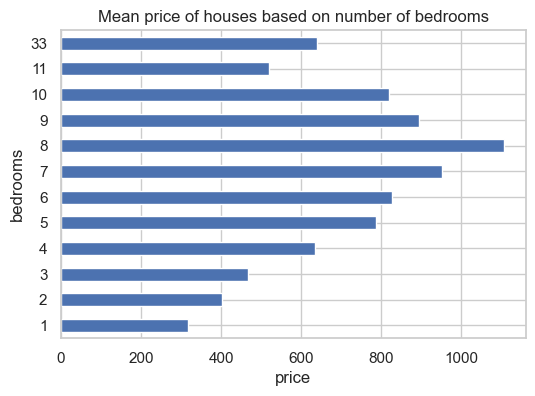

In [8]:
(df.groupby(df['bedrooms'])['price'].mean()/1000).plot.barh()
plt.title("Mean price of houses based on number of bedrooms")
plt.xlabel("price");

# Machine Learning

In [ ]:



predictors = ['bedrooms', 'condition', 'grade']
target = 'price'
X = df[predictors].values
y = df[target].values

# split the data into training and testing sets
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state = 42)

# scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# create classifier object
clf = KNeighborsRegressor(n_neighbors=3)
clf.fit(X_train, y_train)

# predicted prices based on the selected predictor variables
y_pred = clf.predict(X_test)

# printing the first 10 predicted prices
print(y_pred[:10])


[ 233333.33333333  254000.          373333.33333333  362650.
  430816.66666667  757666.66666667  285933.33333333 1399983.33333333
  462000.          373333.33333333]


NameError: name 'c' is not defined